# Notebook 6: Non-parametrics, Permutation Tests & Bootstrap CIs

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 6, Non-parametrics, Permutation Tests & Bootstrap
Confidence Intervals**. The lecture asked a simple but far-reaching question: *what do you do when your
data are not normal?* Reaction times, firing rates and many other neuroscience measurements are skewed,
heavy-tailed and bounded, so the t-test's Gaussian assumptions do not hold. This notebook builds the
toolkit that does not need them: rank-based **non-parametric tests**, **permutation tests** built from
shuffling labels, and **bootstrap confidence intervals** built from resampling with replacement.

We work throughout on real mouse behaviour from the **International Brain Laboratory (IBL)** visual
decision task (`data/ibl_2afc.csv`, the same dataset you met in earlier weeks).

### By the end of this notebook you will be able to:
- Check normality with **histograms and Q–Q plots**, and explain why a **normality test's p-value is
  misleading**, it mostly tracks the sample size, not the shape.
- Summarise skewed data with **robust statistics** (median, IQR, MAD) instead of mean ± SD.
- Choose and run the right **non-parametric test**, **Mann–Whitney U**, **Wilcoxon signed-rank**,
  **Kruskal–Wallis**, **Friedman**, for independent vs paired, two vs many groups.
- Build a **permutation test** from scratch by shuffling labels, and state the **exchangeability**
  assumption it rests on.
- Compute a **bootstrap confidence interval** by resampling with replacement, and **vectorise** it
  across many features at once.
- Derive **Mann–Whitney U** from ranks and report a **rank-biserial / Cliff's δ** effect size.
- Cross-check a Monte-Carlo permutation test against an **exact** enumeration, and compare **percentile
  vs basic** bootstrap intervals.

### Table of contents
1. [Why non-parametrics? Reaction times are not normal](#section-1)
2. [Setting up: loading and tidying the IBL data](#section-2)
3. [Normality checks and robust statistics](#section-3)
4. [Non-parametric tests](#section-4)
5. [Permutation testing and exchangeability](#section-5)
6. [Bootstrap confidence intervals](#section-6)
7. [Lego-style exercises](#section-7)
8. [Many features at once: a vectorised bootstrap](#section-8)
9. [Optional (at home): does the bootstrap keep its promise?](#section-9)
10. [About this notebook](#about)

> **How to read this notebook.** Markdown cells explain *why* and the *concept* behind the statistics;
> code cells implement it. Look out for **`▶ Task`** boxes: short exercises where you edit or extend
> the code. Each task carries a difficulty rating, **★** (easy) to **★★★** (hard). If you are stuck,
> ask the TAs. If you use AI help, treat it as a tutor, not a replacement for thinking: you should be
> able to read every line and explain what it does and why. We suggest the course bot:
> https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot

<a id="section-1"></a>
## 1. Why non-parametrics? Reaction times are not normal

Most of the tests from Weeks 4–5 (t-tests, ANOVA) assume the data are **normally distributed**. Much of
neuroscience is not. **Reaction times** are the textbook example: they cannot be negative, they pile up
near a fast floor, and they have a long right tail of slow trials. Fitting a bell curve to them, or
summarising them with mean ± SD, is misleading, because a handful of slow trials drag the mean around.

Three families of tools handle this without a normality assumption:

- **Non-parametric tests** replace the raw values with their **ranks**, so only the *ordering* matters.
- **Permutation tests** build the null distribution directly, by **shuffling the group labels** and asking
  how often chance alone reproduces the effect you saw.
- **The bootstrap** builds a confidence interval by **resampling the data with replacement**, letting the
  data stand in for the population.

All three are just *counting and resampling*, a few loops over NumPy arrays. Let's load the data and see
how non-normal reaction times really are.

<a id="section-2"></a>
## 2. Setting up: loading and tidying the IBL data

In [15]:
# --- Import the core scientific stack
import numpy as np                      # numerical computing, random resampling
import pandas as pd                     # data manipulation
import matplotlib.pyplot as plt         # plotting
from cycler import cycler               # custom plot colours
from scipy import stats                 # Q-Q plots, non-parametric tests, distributions

# A little plotting style (feel free to tweak later!)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83", "#2ca02c"]),
})

# One random generator, seeded, so every resampling result below is reproducible.
rng = np.random.default_rng(0)

print(f"NumPy : {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"SciPy : {stats.__name__.split('.')[0]} (scipy)")

NumPy : 2.5.2
pandas: 3.0.5
SciPy : scipy (scipy)


We load the trial-level table and tidy it into the table we actually want to analyse, exactly as in the
Regression notebook:

- keep **decidable** trials only, a real choice (`no_go == False`) on the **trained** phase;
- a reaction time is **valid** only inside the IBL window $[0.08, 2.0]$ s (outside it the RT is not a
  response to the stimulus);
- add `abs_contrast` (= |signed contrast| = trial difficulty), and attach each mouse's **sex** and **lab**
  from the subject table.

In [16]:
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
trials_df = pd.read_csv(ROOT / "data" / "ibl_2afc.csv.gz")
subjects = pd.read_csv(ROOT / "data" / "ibl_2afc_subjects.csv")
df = trials_df
df.head()

,trial_id,subject_id,phase,session,trial_in_session,signed_contrast,stimulus_side,response,correct,no_go,reaction_time_s,response_time_s,probability_left,reward_volume,stim_on_time_s,go_cue_time_s,first_movement_time_s,choice_time_s,feedback_time_s
0,0,CSHL051,training,1,1,0.5,right,1.0,1.0,False,NaN,14.5992,0.5,3.0,3.3260,3.3438,NaN,17.9252,17.9252
1,1,CSHL051,training,1,2,1.0,right,0.0,0.0,False,5.1798,6.1442,0.5,0.0,22.4601,22.4895,27.6399,28.6043,28.6373
2,2,CSHL051,training,1,3,1.0,right,0.0,0.0,False,7.4795,7.7830,0.9,0.0,32.5464,32.5760,40.0259,40.3294,40.3646
3,3,CSHL051,training,1,4,-1.0,left,1.0,0.0,False,0.0693,0.8333,0.8,0.0,43.8886,43.9192,43.9579,44.7219,44.7526
4,4,CSHL051,training,1,5,-1.0,left,0.0,1.0,False,18.5863,18.7185,0.8,3.0,48.7176,48.7554,67.3039,67.4361,67.4361


In [17]:
# # --- Load the trial-level IBL dataset (ships gzipped; pandas reads .gz transparently)
# try:
#     df = pd.read_csv("data/ibl_2afc.csv")
# except FileNotFoundError:
#     df = pd.read_csv("data/ibl_2afc.csv.gz")
# subjects = pd.read_csv("data/ibl_2afc_subjects.csv")[["subject_id", "sex", "lab"]]
# print("raw trials:", df.shape, "| subjects:", subjects.shape[0])
# df.head()

# --- Load the trial-level IBL dataset (ships gzipped; pandas reads .gz transparently)

subjects = subjects[["subject_id", "sex", "lab"]]
print("raw trials:", df.shape, "| subjects:", subjects.shape[0])
df.head()

raw trials: (694182, 19) | subjects: 30


,trial_id,subject_id,phase,session,trial_in_session,signed_contrast,stimulus_side,response,correct,no_go,reaction_time_s,response_time_s,probability_left,reward_volume,stim_on_time_s,go_cue_time_s,first_movement_time_s,choice_time_s,feedback_time_s
0,0,CSHL051,training,1,1,0.5,right,1.0,1.0,False,NaN,14.5992,0.5,3.0,3.3260,3.3438,NaN,17.9252,17.9252
1,1,CSHL051,training,1,2,1.0,right,0.0,0.0,False,5.1798,6.1442,0.5,0.0,22.4601,22.4895,27.6399,28.6043,28.6373
2,2,CSHL051,training,1,3,1.0,right,0.0,0.0,False,7.4795,7.7830,0.9,0.0,32.5464,32.5760,40.0259,40.3294,40.3646
3,3,CSHL051,training,1,4,-1.0,left,1.0,0.0,False,0.0693,0.8333,0.8,0.0,43.8886,43.9192,43.9579,44.7219,44.7526
4,4,CSHL051,training,1,5,-1.0,left,0.0,1.0,False,18.5863,18.7185,0.8,3.0,48.7176,48.7554,67.3039,67.4361,67.4361


In [18]:
# --- Tidy: trained, decidable trials with a valid reaction time
RT_LO, RT_HI = 0.08, 2.0                                       # IBL validity window (s)
trials = df[(df["phase"] == "trained") & (~df["no_go"])].copy()
trials["abs_contrast"] = trials["signed_contrast"].abs()
valid  = trials[trials["reaction_time_s"].between(RT_LO, RT_HI)].copy()
valid  = valid.merge(subjects, on="subject_id", how="left")   # attach sex, lab

# One robust number per mouse: the median reaction time (our main sampling unit).
subj_rt = (valid.groupby("subject_id")
                .agg(median_rt=("reaction_time_s", "median"),
                     accuracy=("correct", "mean"),
                     sex=("sex", "first"), lab=("lab", "first"))
                .reset_index())
print(f"{len(valid):,} valid trials across {valid['subject_id'].nunique()} mice")
print(f"per-mouse table: {subj_rt.shape}")
subj_rt.head()

95,396 valid trials across 30 mice
per-mouse table: (30, 5)


,subject_id,median_rt,accuracy,sex,lab
0,CSHL045,0.1994,0.825109,M,churchlandlab
1,CSHL046,0.2439,0.807052,M,churchlandlab
2,CSHL047,0.1589,0.734788,M,churchlandlab
3,CSHL049,0.1945,0.810878,M,churchlandlab
4,CSHL051,0.1531,0.764115,F,churchlandlab


> **▶ Task 2a: Inspect the reaction-time distribution. ★**
>
> Using the cell below:
> 1. Print the **mean** and the **median** reaction time across all valid trials. Which is larger, and why?
> 2. Print the 1st, 50th and 99th **percentiles** of `reaction_time_s` (hint: `np.percentile`).
> 3. Print how many mice are male vs female (hint: `subj_rt["sex"].value_counts()`).

In [19]:
# TODO 2a - fill in the blanks marked ____, uncomment, and run, then answer in the comment.
rt = valid["reaction_time_s"].to_numpy()

# print(f"mean   RT: {rt.____():.3f}          # (1) the mean of rt s")
# print(f"median RT: {np.median(rt):.3f} s   (< mean: the long tail pulls the mean up)")
# print(f"percentiles 1/50/99: {np.percentile(rt, [1, 50, 99]).round(3)} s")
# print(subj_rt["sex"].value_counts())
# # Then answer here: why is the median so much smaller than the mean?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
print(f"mean   RT: {rt.mean():.3f} s")
print(f"median RT: {np.median(rt):.3f} s   (< mean: the long tail pulls the mean up)")
print(f"percentiles 1/50/99: {np.percentile(rt, [1, 50, 99]).round(3)} s")
print(subj_rt["sex"].value_counts())
# --- END SOLUTION


mean   RT: 0.295 s
median RT: 0.176 s   (< mean: the long tail pulls the mean up)
percentiles 1/50/99: [0.082 0.176 1.78 ] s
sex
M    20
F    10
Name: count, dtype: int64


<a id="section-3"></a>
## 3. Normality checks and robust statistics

Before choosing a test, look at the shape of the data. Two visual tools and one warning.

- A **histogram** shows the distribution directly.
- A **Q–Q plot** (quantile–quantile) plots the sorted data against the quantiles a *normal* distribution
  would produce. If the data are normal, the points fall on a straight line; systematic curves reveal
  skew (a bending tail) or heavy tails (S-shape).
- A **normality test** (Shapiro–Wilk, D'Agostino) returns a p-value for "the data are normal". It is
  **treacherous**: with large $n$ it flags trivially small, harmless deviations as "significant"; with
  small $n$ it is too weak to detect real non-normality. The p-value mostly reports your sample size.

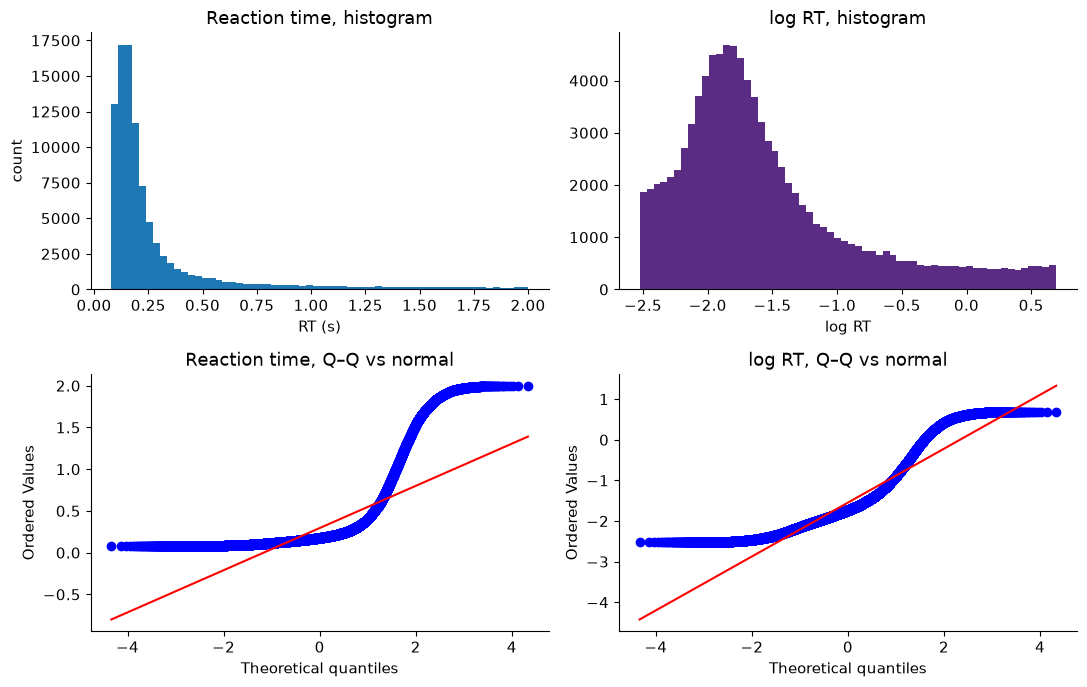

Raw RT bends sharply away from the line (strong right skew).
Taking the log helps a lot, but the tails still deviate, RT is not truly normal.


In [20]:
# --- Histograms and Q-Q plots: raw vs log reaction time (provided)
rt = valid["reaction_time_s"].to_numpy()
logrt = np.log(rt)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].hist(rt, bins=60, color="#1f77b4"); axes[0, 0].set_title("Reaction time, histogram")
axes[0, 0].set_xlabel("RT (s)"); axes[0, 0].set_ylabel("count")
axes[0, 1].hist(logrt, bins=60, color="#5b2c83"); axes[0, 1].set_title("log RT, histogram")
axes[0, 1].set_xlabel("log RT")
stats.probplot(rt, dist="norm", plot=axes[1, 0]);   axes[1, 0].set_title("Reaction time, Q–Q vs normal")
stats.probplot(logrt, dist="norm", plot=axes[1, 1]); axes[1, 1].set_title("log RT, Q–Q vs normal")
plt.tight_layout(); plt.show()
print("Raw RT bends sharply away from the line (strong right skew).")
print("Taking the log helps a lot, but the tails still deviate, RT is not truly normal.")

> **▶ Task 3a: Which test for a difference between two conditions? ★**
>
> The Q–Q plots show that reaction times are clearly **not normal**. Suppose you want to test whether RT
> differs between **two conditions** (say two contrast levels, or two block priors). Thinking back to the
> lecture:
> 1. Which test would you use if the two conditions come from **different, independent** trials/mice?
> 2. Which test if the **same** mice are measured in **both** conditions (paired)?
> 3. Why is a Student's *t*-test a poor choice for these reaction times?

<details>
<summary>✅ Answers (click to show)</summary>

1. **Independent** groups → **Mann–Whitney U** test.
2. **Paired** measurements (the same mice in both conditions) → **Wilcoxon signed-rank** test.
3. Reaction times are **skewed and heavy-tailed**, so the t-test's **normality** assumption is violated and
   its mean-based statistic is dragged around by the slow-RT tail. Rank-based tests use only the *ordering*
   of the values, so they don't need normality. (We build both in §4.)

</details>

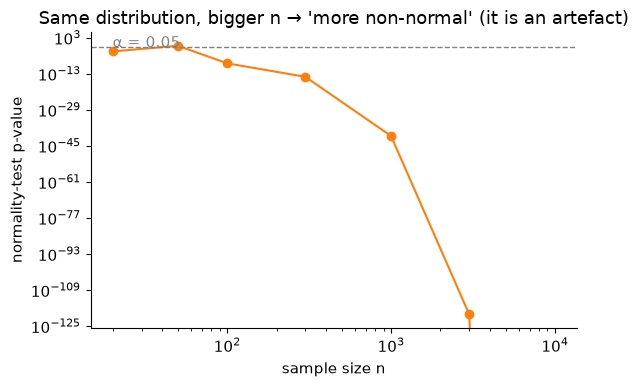

The log-RT distribution never changes shape, only n changes. Yet the p-value collapses
toward 0 as n grows: with enough data, ANY real distribution is 'significantly non-normal'.
Moral: judge normality by eye (Q–Q), not by a p-value; and prefer methods that don't need it.


In [21]:
# --- Why the normality test misleads: its p-value tracks sample size (provided)
sizes = [20, 50, 100, 300, 1000, 3000, 10000]
pvals = []
for n in sizes:
    sample = rng.choice(logrt, size=n, replace=False)      # a random n of the (log) RTs
    pvals.append(stats.normaltest(sample).pvalue)          # D'Agostino test for normality

fig, ax = plt.subplots()
ax.loglog(sizes, pvals, "o-", color="#ff7f0e")
ax.axhline(0.05, ls="--", color="gray", lw=1); ax.text(sizes[0], 0.06, "α = 0.05", color="gray")
ax.set_xlabel("sample size n"); ax.set_ylabel("normality-test p-value")
ax.set_title("Same distribution, bigger n → 'more non-normal' (it is an artefact)")
plt.tight_layout(); plt.show()
print("The log-RT distribution never changes shape, only n changes. Yet the p-value collapses")
print("toward 0 as n grows: with enough data, ANY real distribution is 'significantly non-normal'.")
print("Moral: judge normality by eye (Q–Q), not by a p-value; and prefer methods that don't need it.")

### 3.1 Robust statistics

If the mean and standard deviation are pulled around by the tail, use summaries built on **ranks and
distances from the middle**: the **median**, the **inter-quartile range** (IQR = 75th − 25th percentile),
and the **median absolute deviation** (MAD = median of $|x - \text{median}|$). These barely move when you
add an outlier, that is exactly what "robust" means.

> **▶ Task 3b: Mean vs median under an outlier. ★**
>
> With ~95 000 trials a single outlier is diluted, so work on a **small sample of 50 trials** where its
> effect is visible.
> 1. Draw 50 reaction times, then compute their **mean**, **median**, **SD**, **IQR** and **MAD**. Compute
>    the **IQR by hand** as the 75th minus the 25th percentile (`np.percentile(x, 75) - np.percentile(x, 25)`),
>    and use `stats.median_abs_deviation` for the MAD.
> 2. Append a single absurd 60-second reaction time and recompute all four.
> 3. In a comment: which summaries barely moved (the **robust** ones: median, IQR, MAD) and which jumped
>    (mean, SD)? That is why we report **median ± IQR/MAD** for reaction times.

In [22]:
# TODO 3b - fill in the blanks marked ____, uncomment, and run, then answer in the comment.
# Use a SMALL sample so a single outlier is not diluted by the ~95k trials.

# sample = np.random.default_rng(1).choice(rt, size=50, replace=False)
#
# def summarise(x):
#     return dict(mean=np.mean(x), median=np.median(x), sd=np.std(x),
#                 iqr=np.percentile(x, 75) - np.percentile(x, ____)   # (1) the 25th percentile,   # IQR by hand: 75th - 25th pct
#                 mad=stats.median_abs_deviation(x))
#
# before = summarise(sample)
# after  = summarise(np.append(sample, 60.0))   # add one absurd 60 s trial
# for k in before:
#     print(f"{k:6s}: {before[k]:.3f}  ->  {after[k]:.3f}")
# # mean and SD jump; median, IQR and MAD barely move -> robust stats resist outliers.
# # Then answer here: which summaries barely moved (robust), and which jumped?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
sample = np.random.default_rng(1).choice(rt, size=50, replace=False)

def summarise(x):
    return dict(mean=np.mean(x), median=np.median(x), sd=np.std(x),
                iqr=np.percentile(x, 75) - np.percentile(x, 25),   # IQR by hand: 75th - 25th pct
                mad=stats.median_abs_deviation(x))

before = summarise(sample)
after  = summarise(np.append(sample, 60.0))   # add one absurd 60 s trial
for k in before:
    print(f"{k:6s}: {before[k]:.3f}  ->  {after[k]:.3f}")
# mean and SD jump; median, IQR and MAD barely move -> robust stats resist outliers.
# --- END SOLUTION


mean  : 0.297  ->  1.468
median: 0.190  ->  0.193
sd    : 0.365  ->  8.286
iqr   : 0.133  ->  0.135
mad   : 0.061  ->  0.065


<a id="section-4"></a>
## 4. Non-parametric tests

Rank-based tests replace the raw values with their **ranks** and ask whether one group tends to produce
**larger values** than another. They drop the t-test's **normality** assumption, but they are **not
assumption-free**: they still need the observations to be **independent** (or correctly **paired**), on a
**comparable measurement scale**, and with roughly **similar distribution shapes** across groups. That last
one matters, only when the shapes are alike can we read a Mann–Whitney result as a **shift in medians**
rather than the vaguer "one group tends to score higher". Pick the test from two questions: are the groups
**independent or paired**, and are there **two or more** of them?

| | two groups | more than two groups |
|---|---|---|
| **independent** | Mann–Whitney U | Kruskal–Wallis |
| **paired / repeated** | Wilcoxon signed-rank | Friedman |

We use the per-mouse median reaction time as the unit throughout (30 mice, clearly non-normal).

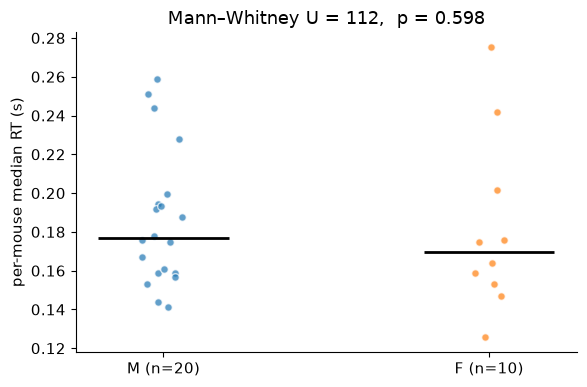

median RT: M = 0.177 s, F = 0.169 s
p = 0.598: no evidence of a sex difference in reaction time.


In [23]:
# --- Mann–Whitney U: independent two groups (male vs female mice) (provided)
male   = subj_rt.loc[subj_rt["sex"] == "M", "median_rt"]
female = subj_rt.loc[subj_rt["sex"] == "F", "median_rt"]
U, p = stats.mannwhitneyu(male, female)

fig, ax = plt.subplots()
for i, (grp, lab) in enumerate([(male, "M"), (female, "F")]):
    ax.scatter(np.full(len(grp), i) + rng.normal(0, 0.04, len(grp)), grp,
               alpha=0.7, s=30, edgecolor="white")
    ax.hlines(grp.median(), i - 0.2, i + 0.2, color="black", lw=2)   # group median
ax.set_xticks([0, 1]); ax.set_xticklabels([f"M (n={len(male)})", f"F (n={len(female)})"])
ax.set_ylabel("per-mouse median RT (s)")
ax.set_title(f"Mann–Whitney U = {U:.0f},  p = {p:.3f}")
plt.tight_layout(); plt.show()
print(f"median RT: M = {male.median():.3f} s, F = {female.median():.3f} s")
print(f"p = {p:.3f}: no evidence of a sex difference in reaction time.")

### Mann–Whitney by hand: from ranks to U (and an effect size)

`scipy` handed us a number, let's rebuild it from the slides. Pool the $n_1+n_2$ values and **rank** them.
With $R_1$ = the sum of ranks of group 1,

$$U_1 = R_1 - \frac{n_1(n_1+1)}{2}, \qquad U_2 = n_1 n_2 - U_1, \qquad U_1 + U_2 = n_1 n_2 .$$

$U_1$ counts how often a group-1 value beats a group-2 value (ties count as ½), and
`scipy.stats.mannwhitneyu` returns exactly $U_1$ for its first argument. A p-value says *whether* there is
a difference; an **effect size** says *how big*. For ranks, the **rank-biserial correlation** (equivalently
**Cliff's delta**) rescales $U$ to $[-1, 1]$:

$$\delta = \frac{U_1 - U_2}{n_1 n_2} = \frac{2U_1}{n_1 n_2} - 1 .$$

$\delta = 0$ = complete overlap; $\pm 1$ = one group entirely above the other. Rules of thumb:
$|\delta| < 0.15$ negligible, ${\approx}\,0.33$ medium, $> 0.47$ large.

> **▶ Task 4a: Mann–Whitney from scratch, with an effect size. ★★**
>
> For the male vs female per-mouse median RTs:
> 1. Rank the pooled values with `stats.rankdata`, sum the male ranks for $R_1$, and compute $U_1$, $U_2$.
> 2. Assert $U_1 + U_2 = n_1 n_2$, and that $U_1$ equals `stats.mannwhitneyu(male, female).statistic`.
> 3. Compute the rank-biserial / Cliff's $\delta$ effect size and say (in a comment) how big the effect is.

In [24]:
# TODO 4a - fill in the blanks marked ____, uncomment, and run, then answer in the comment.

# n1, n2 = len(male), len(female)
# ranks  = stats.rankdata(np.concatenate([male, female]))
# R1     = ranks[:n1].sum()  # (male ranks first)
# U1     = R1 - ____                    # (1) subtract n1*(n1+1)/2
# U2     = n1 * n2 - ____               # (2) since U1 + U2 = n1*n2
# print(f'R1 = {R1:.1f}   U1 = {U1:.1f}   U2 = {U2:.1f}   U1+U2 = {U1+U2:.0f}  (= n1*n2 = {n1*n2})')
# assert np.isclose(U1 + U2, n1 * n2)
# assert np.isclose(U1, stats.mannwhitneyu(male, female).statistic)
# delta = (U1 - U2) / (n1 * n2)  # Cliff's delta = rank-biserial
# print(f'rank-biserial / Cliff delta = {delta:+.3f}  ->  a negligible effect (|delta| < 0.15).')
# # Then answer here: is the effect large or negligible, and how do you read Cliff's delta?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
n1, n2 = len(male), len(female)
ranks  = stats.rankdata(np.concatenate([male, female]))
R1     = ranks[:n1].sum()  # (male ranks first)
U1     = R1 - n1 * (n1 + 1) / 2
U2     = n1 * n2 - U1
print(f'R1 = {R1:.1f}   U1 = {U1:.1f}   U2 = {U2:.1f}   U1+U2 = {U1+U2:.0f}  (= n1*n2 = {n1*n2})')
assert np.isclose(U1 + U2, n1 * n2)
assert np.isclose(U1, stats.mannwhitneyu(male, female).statistic)
delta = (U1 - U2) / (n1 * n2)  # Cliff's delta = rank-biserial
print(f'rank-biserial / Cliff delta = {delta:+.3f}  ->  a negligible effect (|delta| < 0.15).')
# --- END SOLUTION


R1 = 322.5   U1 = 112.5   U2 = 87.5   U1+U2 = 200  (= n1*n2 = 200)
rank-biserial / Cliff delta = +0.125  ->  a negligible effect (|delta| < 0.15).


### Wilcoxon signed-rank test
**Paired data** need a paired test. Each mouse was recorded in an early **training** phase and later
when **trained**, two measurements of the *same* mouse, so we compare them with the **Wilcoxon
signed-rank** test on the within-mouse differences.

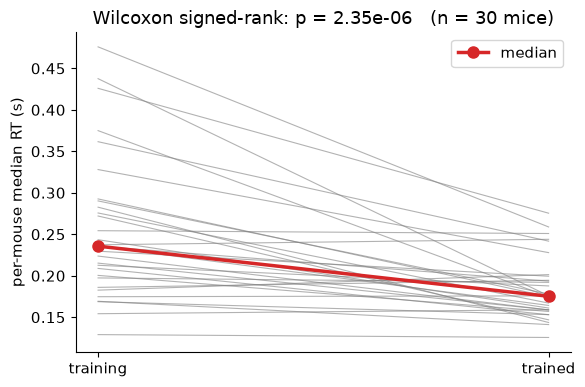

Mice get faster with training (median RT 0.236 -> 0.175 s); the paired test is highly significant.


In [25]:
# --- Wilcoxon signed-rank: paired (training vs trained, same mice) (provided)
def phase_median_rt(phase):
    d = df[(df["phase"] == phase) & (~df["no_go"])]
    d = d[d["reaction_time_s"].between(RT_LO, RT_HI)]
    return d.groupby("subject_id")["reaction_time_s"].median()

paired = pd.concat([phase_median_rt("training").rename("training"),
                    phase_median_rt("trained").rename("trained")], axis=1).dropna()
stat, p = stats.wilcoxon(paired["training"], paired["trained"])

fig, ax = plt.subplots()
for _, row in paired.iterrows():
    ax.plot([0, 1], [row["training"], row["trained"]], color="gray", lw=0.8, alpha=0.6)
ax.plot([0, 1], [paired["training"].median(), paired["trained"].median()],
        "o-", color="#d62728", lw=2.5, ms=8, label="median")
ax.set_xticks([0, 1]); ax.set_xticklabels(["training", "trained"])
ax.set_ylabel("per-mouse median RT (s)")
ax.set_title(f"Wilcoxon signed-rank: p = {p:.2e}   (n = {len(paired)} mice)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Mice get faster with training (median RT {paired['training'].median():.3f} -> "
      f"{paired['trained'].median():.3f} s); the paired test is highly significant.")

### 4.1 More than two groups: Kruskal–Wallis vs Friedman

With three or more groups we need the rank-based analogues of ANOVA. Which one depends on **how the
groups were obtained**:

- **Kruskal–Wallis** is the non-parametric **one-way ANOVA**. It asks: *do* $k$ **independent** *groups
  come from the same distribution, or does at least one tend to give larger values?* Use it when the
  observations in the different groups are **separate and unrelated** (e.g. different trials, or different
  animals in each group).
- **Friedman** is the non-parametric **repeated-measures ANOVA**. It asks the same question but for
  **matched** data: the *same* subjects (here, mice) are each measured under **every** condition. It ranks
  the conditions **within each subject** first, so it removes the between-subject differences in overall
  speed and only tests the *condition* effect. Use it when the conditions are **paired within subject**.

Our question, *does reaction time depend on difficulty (|contrast|)?*, can be framed either way, which
makes it a clean side-by-side:

- **Kruskal–Wallis** on the **raw trials** grouped by contrast: every trial is treated as one independent
  observation.
- **Friedman** on **one median per (mouse, contrast)**: each mouse contributes one value at every contrast
  level, so difficulty is a *within-mouse* manipulation.

The Friedman framing is the sounder one here: trials from the same mouse are **not** truly independent
(that is *pseudoreplication*, which inflates Kruskal–Wallis), and difficulty really is manipulated within
each animal. We run both so you can see how the design choice, not just the data, shapes the test.

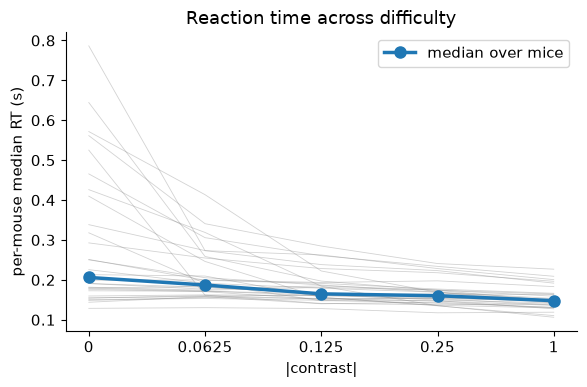

Kruskal–Wallis (independent): H = 3831.2,  p = 0.00e+00
Friedman (repeated measures): chi2 = 88.3,  p = 2.99e-18
Both reject 'RT is the same at every contrast', mice slow down on hard trials.


In [26]:
# --- Kruskal–Wallis (independent) and Friedman (repeated) across contrast (provided)
levels = sorted(valid["abs_contrast"].unique())

# Kruskal–Wallis on the raw trials grouped by contrast
kw_groups = [valid.loc[valid["abs_contrast"] == c, "reaction_time_s"].values for c in levels]
H, p_kw = stats.kruskal(*kw_groups)

# Friedman on one median per (mouse, contrast), keep mice measured at every level
pivot = (valid.pivot_table(index="subject_id", columns="abs_contrast",
                           values="reaction_time_s", aggfunc="median").dropna())
chi, p_fr = stats.friedmanchisquare(*[pivot[c].values for c in pivot.columns])

fig, ax = plt.subplots()
xpos = np.arange(len(levels))
for _, row in pivot.iterrows():
    ax.plot(xpos, row.values, color="gray", lw=0.6, alpha=0.35)
ax.plot(xpos, pivot.median().values, "o-", color="#1f77b4", lw=2.5, ms=8, label="median over mice")
ax.set_xticks(xpos); ax.set_xticklabels([f"{c:g}" for c in levels])
ax.set_xlabel("|contrast|"); ax.set_ylabel("per-mouse median RT (s)")
ax.set_title("Reaction time across difficulty")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Kruskal–Wallis (independent): H = {H:.1f},  p = {p_kw:.2e}")
print(f"Friedman (repeated measures): chi2 = {chi:.1f},  p = {p_fr:.2e}")
print("Both reject 'RT is the same at every contrast', mice slow down on hard trials.")

> **▶ Task 4b: Does accuracy depend on difficulty? ★★**
>
> Repeat the **Friedman** analysis, but for **accuracy** instead of reaction time: build one accuracy value
> per (mouse, |contrast|), keep mice measured at every level, and run `stats.friedmanchisquare`.
>
> 1. Report the p-value.
> 2. Plot the per-mouse accuracy-vs-contrast curves with the median overlaid (like the RT figure above).
> 3. In a comment: is the psychometric effect (accuracy vs difficulty) as clear as the chronometric one?

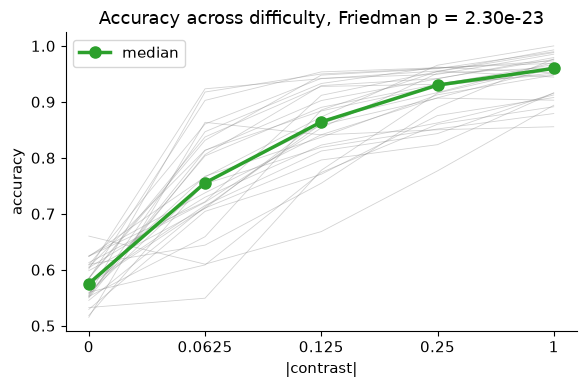

Friedman on accuracy: chi2 = 112.3, p = 2.30e-23, accuracy rises steeply with contrast.


In [27]:
# TODO 4b - fill in the blanks marked ____, uncomment, and run.

# acc_pivot = (valid.pivot_table(index="subject_id", columns="abs_contrast",
#                                values="correct", aggfunc="mean").dropna())
# chi, p = stats.friedmanchisquare(*[acc_pivot[c].values for c in ____])   # (1) one array per contrast column
#
# fig, ax = plt.subplots()
# xpos = np.arange(acc_pivot.shape[1])
# for _, row in acc_pivot.iterrows():
#     ax.plot(xpos, row.values, color="gray", lw=0.6, alpha=0.35)
# ax.plot(xpos, acc_pivot.median().values, "o-", color="#2ca02c", lw=2.5, ms=8, label="median")
# ax.set_xticks(xpos); ax.set_xticklabels([f"{c:g}" for c in acc_pivot.columns])
# ax.set_xlabel("|contrast|"); ax.set_ylabel("accuracy"); ax.legend()
# ax.set_title(f"Accuracy across difficulty, Friedman p = {p:.2e}")
# plt.tight_layout(); plt.show()
# print(f"Friedman on accuracy: chi2 = {chi:.1f}, p = {p:.2e}, accuracy rises steeply with contrast.")

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
acc_pivot = (valid.pivot_table(index="subject_id", columns="abs_contrast",
                               values="correct", aggfunc="mean").dropna())
chi, p = stats.friedmanchisquare(*[acc_pivot[c].values for c in acc_pivot.columns])

fig, ax = plt.subplots()
xpos = np.arange(acc_pivot.shape[1])
for _, row in acc_pivot.iterrows():
    ax.plot(xpos, row.values, color="gray", lw=0.6, alpha=0.35)
ax.plot(xpos, acc_pivot.median().values, "o-", color="#2ca02c", lw=2.5, ms=8, label="median")
ax.set_xticks(xpos); ax.set_xticklabels([f"{c:g}" for c in acc_pivot.columns])
ax.set_xlabel("|contrast|"); ax.set_ylabel("accuracy"); ax.legend()
ax.set_title(f"Accuracy across difficulty, Friedman p = {p:.2e}")
plt.tight_layout(); plt.show()
print(f"Friedman on accuracy: chi2 = {chi:.1f}, p = {p:.2e}, accuracy rises steeply with contrast.")
# --- END SOLUTION


<a id="section-5"></a>
## 5. Permutation testing and exchangeability

A permutation test builds the null distribution **from your own data**, with almost no assumptions. The
logic: if a grouping label (say sex) has *no* effect, then it is just an arbitrary tag, we could **shuffle
the labels** among the animals and the result should look the same. So:

1. Compute the observed statistic (e.g. the difference in group medians).
2. **Shuffle the labels** many times; each time recompute the statistic. This is the null distribution, 
   what chance alone produces **given this particular empirical data distribution**.
3. The **p-value** is the fraction of shuffles whose statistic is at least as extreme as the observed one.

The one assumption is **exchangeability**: under the null, the observations are interchangeable across
groups. Shuffling is sampling **without replacement** (a *permutation* of the labels). There are far too
many permutations to enumerate, $\binom{30}{10}$ is ~30 million here, so we draw a large random sample of
them (a Monte-Carlo permutation test).

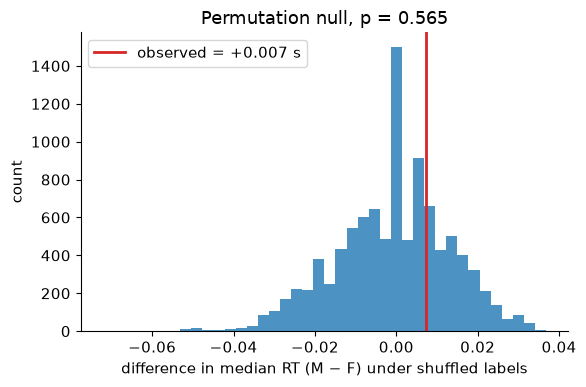

Observed M−F difference +0.007 s sits well inside the null cloud (p = 0.565).
Mann–Whitney on the same data gives p = 0.598: the two methods agree, no sex effect.


In [28]:
# --- Permutation test: difference in median RT, male vs female (provided) ---
obs_diff = male.median() - female.median()          # observed statistic
pooled   = np.concatenate([male.values, female.values])
n_male   = len(male)

N_PERM = 10_000
perm_diffs = np.empty(N_PERM)
for i in range(N_PERM):                              # loop for resampling (permutation)
    shuffled = rng.permutation(pooled)              # shuffle labels = sample WITHOUT replacement
    perm_diffs[i] = np.median(shuffled[:n_male]) - np.median(shuffled[n_male:])

p_perm = np.mean(np.abs(perm_diffs) >= abs(obs_diff))   # two-sided

fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=40, color="#1f77b4", alpha=0.8)
ax.axvline(obs_diff, color="#d62728", lw=2, label=f"observed = {obs_diff:+.3f} s")
ax.set_xlabel("difference in median RT (M − F) under shuffled labels")
ax.set_ylabel("count"); ax.set_title(f"Permutation null, p = {p_perm:.3f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Observed M−F difference {obs_diff:+.3f} s sits well inside the null cloud (p = {p_perm:.3f}).")
_, p_mwu = stats.mannwhitneyu(male, female)
print(f"Mann–Whitney on the same data gives p = {p_mwu:.3f}: the two methods agree, no sex effect.")

> **▶ Task 5a: Permute a real effect. ★★**
>
> The training→trained speed-up was highly significant (Wilcoxon). Test it with a **paired permutation**
> instead. For paired data the exchangeable unit is the **sign** of each mouse's difference: under the
> null, `trained − training` is equally likely to be $+$ or $-$.
>
> 1. Compute `d = paired["trained"] - paired["training"]` and the observed **mean difference**.
> 2. In a loop, multiply each `d` by a random $\pm 1$ (`rng.choice([-1, 1], size=len(d))`) and record the
>    mean. Do this 10 000 times to build the null.
> 3. Report the two-sided p-value and plot the null with the observed value marked.

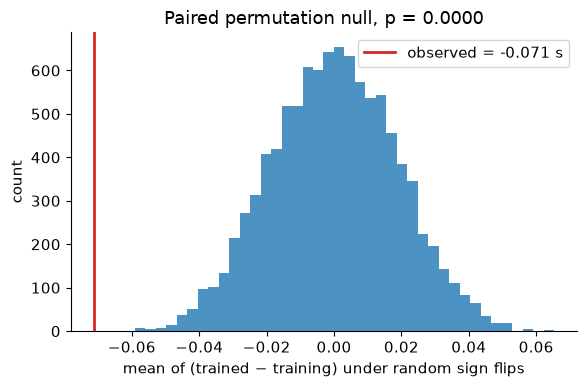

observed mean speed-up -0.071 s; permutation p = 0.0000 (far outside the null).


In [29]:
# TODO 5a - fill in the blanks marked ____, uncomment, and run, then answer in the comment.

# d = (paired["trained"] - paired["training"]).to_numpy()
# obs = d.mean()
#
# N = 10_000
# null = np.empty(N)
# for i in range(N):
#     signs = rng.choice([____], size=len(d))    # (1) random +1 / -1 flips
#     null[i] = np.mean(____ * d)                # (2) apply the flips to d
# p_perm = np.mean(np.abs(null) >= abs(obs))
#
# fig, ax = plt.subplots()
# ax.hist(null, bins=40, color="#1f77b4", alpha=0.8)
# ax.axvline(obs, color="#d62728", lw=2, label=f"observed = {obs:+.3f} s")
# ax.set_xlabel("mean of (trained − training) under random sign flips")
# ax.set_ylabel("count"); ax.set_title(f"Paired permutation null, p = {p_perm:.4f}")
# ax.legend(); plt.tight_layout(); plt.show()
# print(f"observed mean speed-up {obs:+.3f} s; permutation p = {p_perm:.4f} (far outside the null).")
# # Then answer here: is the training speed-up real, or could it be chance?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
d = (paired["trained"] - paired["training"]).to_numpy()
obs = d.mean()

N = 10_000
null = np.empty(N)
for i in range(N):
    signs = rng.choice([-1, 1], size=len(d))
    null[i] = np.mean(signs * d)
p_perm = np.mean(np.abs(null) >= abs(obs))

fig, ax = plt.subplots()
ax.hist(null, bins=40, color="#1f77b4", alpha=0.8)
ax.axvline(obs, color="#d62728", lw=2, label=f"observed = {obs:+.3f} s")
ax.set_xlabel("mean of (trained − training) under random sign flips")
ax.set_ylabel("count"); ax.set_title(f"Paired permutation null, p = {p_perm:.4f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed mean speed-up {obs:+.3f} s; permutation p = {p_perm:.4f} (far outside the null).")
# --- END SOLUTION


> **▶ Task 5b: Direction of the difference. ★**
>
> Task 5a tested `trained − training`. What would change if you instead tested `training − trained`?
> Reason about the observed statistic and the shape of the sign-flip null *before* re-running the code.

<details>
<summary>✅ Answer (click to show)</summary>

Only the **sign** of the observed mean flips. The sign-flip null is **symmetric about 0**, so the two-sided
p-value is **unchanged**, a permutation test detects *that* there is a difference, not its direction.

</details>

### Exact vs Monte-Carlo: why we sample

A permutation test's null is, in principle, **exact**: enumerate *every* way to split the data into the two
group sizes, recompute the statistic each time, and count. The catch is how many splits there are. For our
30 mice in groups of 20 and 10 that is $\binom{30}{10} = \tfrac{30!}{10!\,20!}$, far too many to list, so we
**sample** from them (Monte-Carlo). But for a **tiny** sample we *can* enumerate them all and get an exact
p-value, which is a perfect check on the sampled one.

> **▶ Task 5c: Count the splits; exact vs Monte-Carlo. ★★★**
>
> 1. Print $\binom{30}{10}$ with `math.comb`, the number of label assignments for the real comparison.
> 2. Take a **tiny** subset (the first 5 male and first 4 female median RTs). Enumerate **all**
>    $\binom{9}{5}$ splits with `itertools.combinations`, computing the difference in medians for each, and
>    get the **exact** two-sided permutation p-value.
> 3. Run a 20 000-draw Monte-Carlo permutation on the same subset; check the two p-values agree.

<details>
<summary>💡 Hint (click to show)</summary>

- **Exact:** pool the 9 values. `itertools.combinations(range(9), 5)` yields every way to choose which 5
  positions form group 1 (the other 4 form group 2). For each split compute
  `np.median(group1) - np.median(group2)`, count how often `abs(diff) >= abs(observed)`, and divide by the
  number of splits for the exact two-sided p-value.
- **Monte-Carlo:** same statistic, but instead of enumerating, `rng.permutation(pooled)` many times and take
  the first 5 as group 1. The fraction with `abs(diff) >= abs(observed)` is the sampled p-value.

</details>

In [30]:
# TODO 5c - fill in the blanks marked ____, uncomment, and run.
import math, itertools

# print(f'C(30,10) = {math.comb(30, 10):,}  label assignments  ->  far too many to list, so we sample.')
#
# xs, ys = male.to_numpy()[:5], female.to_numpy()[:4]
# pooled = np.concatenate([xs, ys]); k, N = len(xs), len(xs) + len(ys)
# obs    = np.median(xs) - np.median(ys)
#
# hits = tot = 0
# for idx in itertools.combinations(range(N), k):        # every split into a group of k
#     comp = [j for j in range(N) if j not in idx]
#     d = np.median(pooled[list(idx)]) - np.median(pooled[comp])
#     tot += 1; hits += abs(d) >= abs(obs) - 1e-12
# p_exact = hits / tot
#
# # Conceptually simplest, an explicit loop: shuffle, split, store the median difference.
# mc = []
# for _ in range(20_000):
#     p = rng.permutation(pooled)                    # shuffle the pooled values
#     mc.append(np.median(p[:____]) - np.median(p[____:]))   # (1) split at the group size k
# mc = np.array(mc)
# # Exactly the same, shorter: a list comprehension with the walrus ':=' operator, which assigns
# # the shuffle to p AND returns it, so we shuffle once and can still slice p[:k] / p[k:].
# mc = np.array([np.median((p := rng.permutation(pooled))[:k]) - np.median(p[k:]) for _ in range(20_000)])
# p_mc = np.mean(np.abs(mc) >= abs(obs) - 1e-12)
# print(f'exact: {tot} = C(9,5) splits, p = {p_exact:.3f}   |   Monte-Carlo p = {p_mc:.3f}   (they agree)')

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
print(f'C(30,10) = {math.comb(30, 10):,}  label assignments  ->  far too many to list, so we sample.')

xs, ys = male.to_numpy()[:5], female.to_numpy()[:4]
pooled = np.concatenate([xs, ys]); k, N = len(xs), len(xs) + len(ys)
obs    = np.median(xs) - np.median(ys)

hits = tot = 0
for idx in itertools.combinations(range(N), k):        # every split into a group of k
    comp = [j for j in range(N) if j not in idx]
    d = np.median(pooled[list(idx)]) - np.median(pooled[comp])
    tot += 1; hits += abs(d) >= abs(obs) - 1e-12
p_exact = hits / tot

# Conceptually simplest, an explicit loop: shuffle, split, store the median difference.
mc = []
for _ in range(20_000):
    p = rng.permutation(pooled)                    # shuffle the pooled values
    mc.append(np.median(p[:k]) - np.median(p[k:]))
mc = np.array(mc)
# Exactly the same, shorter: a list comprehension with the walrus ':=' operator, which assigns
# the shuffle to p AND returns it, so we shuffle once and can still slice p[:k] / p[k:].
mc = np.array([np.median((p := rng.permutation(pooled))[:k]) - np.median(p[k:]) for _ in range(20_000)])
p_mc = np.mean(np.abs(mc) >= abs(obs) - 1e-12)
print(f'exact: {tot} = C(9,5) splits, p = {p_exact:.3f}   |   Monte-Carlo p = {p_mc:.3f}   (they agree)')
# --- END SOLUTION


C(30,10) = 30,045,015  label assignments  ->  far too many to list, so we sample.
exact: 126 = C(9,5) splits, p = 0.040   |   Monte-Carlo p = 0.039   (they agree)


<a id="section-6"></a>
## 6. Bootstrap confidence intervals

A permutation test asks "could chance produce this *difference*?". The **bootstrap** asks a different
question: "how *precise* is my estimate?". The idea is to treat the sample as a stand-in for the
population and **resample it with replacement**:

1. Draw a resample of the same size, **with replacement**, from the data.
2. Compute the statistic (e.g. the median) on the resample.
3. Repeat many times; the spread of those values estimates the sampling variability. The **95 % percentile
   confidence interval** is just the 2.5th–97.5th percentiles of the bootstrap distribution.

This works for *any* statistic, median, IQR, a correlation, with no formula for its standard error.

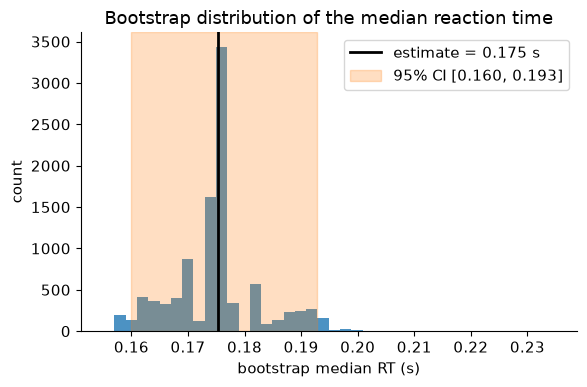

Median RT = 0.175 s, 95% bootstrap CI [0.160, 0.193] s.


In [31]:
# --- Bootstrap CI for the population median reaction time (provided) ---
# Sampling unit = the mouse: resample the 30 per-mouse median RTs with replacement.
x = subj_rt["median_rt"].to_numpy()
B = 10_000
boot = np.empty(B)
for b in range(B):                                  # loop for resampling (with replacement)
    resample = rng.choice(x, size=len(x), replace=True)
    boot[b] = np.median(resample)

lo, hi = np.percentile(boot, [2.5, 97.5])           # 95% percentile CI

fig, ax = plt.subplots()
ax.hist(boot, bins=40, color="#1f77b4", alpha=0.8)
ax.axvline(np.median(x), color="black", lw=2, label=f"estimate = {np.median(x):.3f} s")
ax.axvspan(lo, hi, color="#ff7f0e", alpha=0.25, label=f"95% CI [{lo:.3f}, {hi:.3f}]")
ax.set_xlabel("bootstrap median RT (s)"); ax.set_ylabel("count")
ax.set_title("Bootstrap distribution of the median reaction time")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Median RT = {np.median(x):.3f} s, 95% bootstrap CI [{lo:.3f}, {hi:.3f}] s.")

> **▶ Task 6a: How many resamples is enough? ★★**
>
> Both permutation tests and the bootstrap are **Monte-Carlo**: their answer wobbles if you use too few
> iterations. Quantify that trade-off.
> 1. For the male-vs-female median-RT **permutation** test (§5), recompute the p-value for `N` in
>    `[50, 200, 1000, 5000, 20000]`, repeating each `N` **10 times** with fresh draws. Plot the spread of
>    p-values against `N` (log x-axis).
> 2. For the **bootstrap** median RT (the cell above), recompute the 95% CI **width** for `B` in the same
>    range, again repeated 10 times, and plot the spread of widths against `B`.
> 3. In a comment: roughly how many iterations before the answer stops moving?

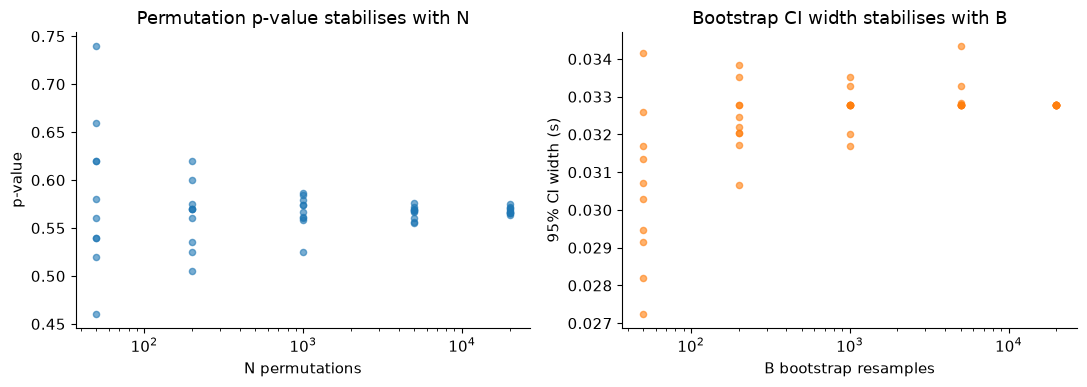

Both scatter clouds shrink as the count grows; by ~5000 iterations the answer barely moves.


In [32]:
# TODO 6a - fill in the blanks marked ____, uncomment, and run.

# counts = [50, 200, 1000, 5000, 20000]; reps = 10
# pooled = np.concatenate([male.values, female.values]); nM = len(male)
# obs = male.median() - female.median()
# perm_p = {N: [] for N in counts}
# for N in counts:
#     for _ in range(reps):
#         d = np.empty(N)
#         for i in range(N):
#             sh = rng.permutation(pooled)
#             d[i] = np.median(sh[:____]) - np.median(sh[____:])   # (1) split at nM (the male count)
#         perm_p[N].append(np.mean(np.abs(d) >= abs(obs)))
# x = subj_rt["median_rt"].to_numpy()
# boot_w = {B: [] for B in counts}
# for B in counts:
#     for _ in range(reps):
#         bs = np.median(rng.choice(x, size=(B, len(x)), replace=True), axis=1)
#         lo, hi = np.percentile(bs, [2.5, 97.5]); boot_w[B].append(hi - lo)
#
# fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# for N in counts:
#     axes[0].scatter([N]*reps, perm_p[N], color="#1f77b4", alpha=0.6, s=20)
#     axes[1].scatter([N]*reps, boot_w[N], color="#ff7f0e", alpha=0.6, s=20)
# axes[0].set_xscale("log"); axes[0].set_xlabel("N permutations"); axes[0].set_ylabel("p-value")
# axes[0].set_title("Permutation p-value stabilises with N")
# axes[1].set_xscale("log"); axes[1].set_xlabel("B bootstrap resamples")
# axes[1].set_ylabel("95% CI width (s)"); axes[1].set_title("Bootstrap CI width stabilises with B")
# plt.tight_layout(); plt.show()
# print("Both scatter clouds shrink as the count grows; by ~5000 iterations the answer barely moves.")

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
counts = [50, 200, 1000, 5000, 20000]; reps = 10
# --- END SOLUTION

# permutation p-value vs N (male vs female median RT)
# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
pooled = np.concatenate([male.values, female.values]); nM = len(male)
obs = male.median() - female.median()
perm_p = {N: [] for N in counts}
for N in counts:
    for _ in range(reps):
        d = np.empty(N)
        for i in range(N):
            sh = rng.permutation(pooled)
            d[i] = np.median(sh[:nM]) - np.median(sh[nM:])
        perm_p[N].append(np.mean(np.abs(d) >= abs(obs)))
# --- END SOLUTION

# bootstrap 95% CI width vs B (median RT across mice)
# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
x = subj_rt["median_rt"].to_numpy()
boot_w = {B: [] for B in counts}
for B in counts:
    for _ in range(reps):
        bs = np.median(rng.choice(x, size=(B, len(x)), replace=True), axis=1)
        lo, hi = np.percentile(bs, [2.5, 97.5]); boot_w[B].append(hi - lo)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for N in counts:
    axes[0].scatter([N]*reps, perm_p[N], color="#1f77b4", alpha=0.6, s=20)
    axes[1].scatter([N]*reps, boot_w[N], color="#ff7f0e", alpha=0.6, s=20)
axes[0].set_xscale("log"); axes[0].set_xlabel("N permutations"); axes[0].set_ylabel("p-value")
axes[0].set_title("Permutation p-value stabilises with N")
axes[1].set_xscale("log"); axes[1].set_xlabel("B bootstrap resamples")
axes[1].set_ylabel("95% CI width (s)"); axes[1].set_title("Bootstrap CI width stabilises with B")
plt.tight_layout(); plt.show()
print("Both scatter clouds shrink as the count grows; by ~5000 iterations the answer barely moves.")
# --- END SOLUTION


> **▶ Task 6b: Bootstrap a difference. ★★ _(optional)_**
>
> Put a confidence interval on the **sex difference** in median RT (male − female), and connect it to the
> permutation test from §5.
>
> 1. Bootstrap the two groups **independently**: on each iteration resample `male` and `female` (each with
>    replacement, each keeping its own size), and record `median(male*) − median(female*)`.
> 2. Report the 95 % percentile CI of that difference.
> 3. In a comment: does the CI include 0? How does that conclusion compare with the permutation p-value?

In [33]:
# TODO 6b - fill in the blanks marked ____, uncomment, and run.

# m = male.to_numpy(); f = female.to_numpy()
# B = 10_000
# diff = np.empty(B)
# for b in range(B):
#     mb = rng.choice(m, size=len(m), replace=____)   # (1) True = with replacement
#     fb = rng.choice(f, size=len(f), replace=True)
#     diff[b] = np.median(mb) - np.median(____)       # (2) the resampled females
# lo, hi = np.percentile(diff, [2.5, 97.5])
# print(f"male − female median RT = {np.median(m) - np.median(f):+.3f} s")
# print(f"95% bootstrap CI: [{lo:+.3f}, {hi:+.3f}] s")
# print("The CI comfortably includes 0, consistent with the permutation test's null result.")

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
m = male.to_numpy(); f = female.to_numpy()
B = 10_000
diff = np.empty(B)
for b in range(B):
    mb = rng.choice(m, size=len(m), replace=True)
    fb = rng.choice(f, size=len(f), replace=True)
    diff[b] = np.median(mb) - np.median(fb)
lo, hi = np.percentile(diff, [2.5, 97.5])
print(f"male − female median RT = {np.median(m) - np.median(f):+.3f} s")
print(f"95% bootstrap CI: [{lo:+.3f}, {hi:+.3f}] s")
print("The CI comfortably includes 0, consistent with the permutation test's null result.")
# --- END SOLUTION


male − female median RT = +0.007 s
95% bootstrap CI: [-0.033, +0.036] s
The CI comfortably includes 0, consistent with the permutation test's null result.


### Percentile vs basic (reverse-percentile) interval

The 95% CI above is the **percentile** interval, the 2.5th and 97.5th percentiles of the bootstrap
distribution. The lecture gives the **basic** (a.k.a. *reverse-percentile*) interval, which
reflects the bootstrap quantiles through the estimate $\hat\theta$:

$$\text{percentile:}\ \big[\,q_{2.5},\; q_{97.5}\,\big] \qquad\qquad
\text{basic:}\ \big[\,2\hat\theta - q_{97.5},\; 2\hat\theta - q_{2.5}\,\big].$$

When the bootstrap distribution is **symmetric** the two coincide. When it is **skewed** they pull apart,
and the basic interval corrects in the direction *opposite* to the skew.

> **▶ Task 6c: Percentile vs basic on a skewed statistic. ★★**
>
> The median's bootstrap is nearly symmetric, so pick a **skewed** statistic: the **90th percentile** of RT
> (the slow-tail edge).
> 1. Bootstrap the 90th percentile of `valid["reaction_time_s"]` (`B = 5000`).
> 2. Compute **both** the percentile CI and the basic CI (formulas above).
> 3. Plot the bootstrap histogram with both intervals marked. By how much do they differ, and which way?

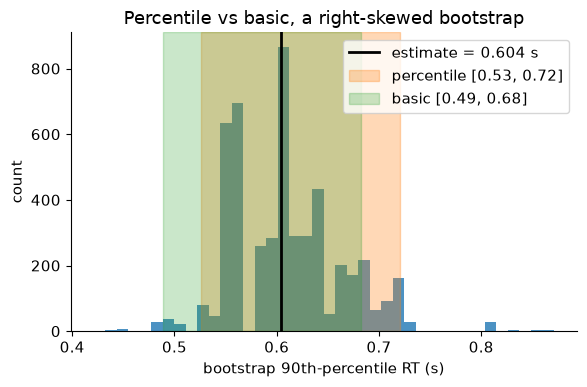

The 90th-percentile bootstrap is right-skewed, so the basic interval sits BELOW the
percentile one (lower edge shifts by -0.037 s). On a symmetric statistic they coincide.


In [34]:
# TODO 6c - fill in the blanks marked ____, uncomment, and run, then answer in the comment.

# rt   = valid["reaction_time_s"].sample(500, random_state=1).to_numpy()  # (small n -> more skew)
# def stat(a): return np.percentile(a, 90)   # the statistic we bootstrap (see the optional lambda note below)
# est, B = stat(rt), 5_000
# boot = np.array([stat(rng.choice(rt, len(rt), replace=True)) for _ in range(B)])
# q_lo, q_hi = np.percentile(boot, [2.5, 97.5])
# pct   = (q_lo, q_hi)  # percentile
# basic = (2*est - ____, 2*est - ____)   # (1) reflect the edges: 2*est - q_hi, 2*est - q_lo  # reverse-percentile
#
# fig, ax = plt.subplots()
# ax.hist(boot, bins=40, color="#1f77b4", alpha=0.8)
# ax.axvline(est, color="black", lw=2, label=f"estimate = {est:.3f} s")
# ax.axvspan(*pct,   color="#ff7f0e", alpha=0.30, label=f"percentile [{pct[0]:.2f}, {pct[1]:.2f}]")
# ax.axvspan(*basic, color="#2ca02c", alpha=0.25, label=f"basic [{basic[0]:.2f}, {basic[1]:.2f}]")
# ax.set_xlabel("bootstrap 90th-percentile RT (s)"); ax.set_ylabel("count"); ax.legend()
# ax.set_title("Percentile vs basic, a right-skewed bootstrap"); plt.tight_layout(); plt.show()
# print(f'The 90th-percentile bootstrap is right-skewed, so the basic interval sits BELOW the')
# print(f'percentile one (lower edge shifts by {basic[0]-pct[0]:+.3f} s). On a symmetric statistic they coincide.')
# # Then answer here: why does the basic interval sit below the percentile one here?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
rt   = valid["reaction_time_s"].sample(500, random_state=1).to_numpy()  # (small n -> more skew)
def stat(a): return np.percentile(a, 90)   # the statistic we bootstrap (see the optional lambda note below)
est, B = stat(rt), 5_000
boot = np.array([stat(rng.choice(rt, len(rt), replace=True)) for _ in range(B)])
q_lo, q_hi = np.percentile(boot, [2.5, 97.5])
pct   = (q_lo, q_hi)  # percentile
basic = (2*est - q_hi, 2*est - q_lo)  # reverse-percentile

fig, ax = plt.subplots()
ax.hist(boot, bins=40, color="#1f77b4", alpha=0.8)
ax.axvline(est, color="black", lw=2, label=f"estimate = {est:.3f} s")
ax.axvspan(*pct,   color="#ff7f0e", alpha=0.30, label=f"percentile [{pct[0]:.2f}, {pct[1]:.2f}]")
ax.axvspan(*basic, color="#2ca02c", alpha=0.25, label=f"basic [{basic[0]:.2f}, {basic[1]:.2f}]")
ax.set_xlabel("bootstrap 90th-percentile RT (s)"); ax.set_ylabel("count"); ax.legend()
ax.set_title("Percentile vs basic, a right-skewed bootstrap"); plt.tight_layout(); plt.show()
print(f'The 90th-percentile bootstrap is right-skewed, so the basic interval sits BELOW the')
print(f'percentile one (lower edge shifts by {basic[0]-pct[0]:+.3f} s). On a symmetric statistic they coincide.')
# --- END SOLUTION


> **Python aside (optional): the `lambda`.** You will sometimes meet a one-line **anonymous function**
> written with `lambda`. For instance `stat = lambda a: np.percentile(a, 90)` does exactly the same as the
> `def stat(a): return np.percentile(a, 90)` above, only shorter, and is handy when you need a quick
> throwaway function to hand to another function. You never *have* to use it, a normal `def` always works.


> **▶ Task 6d: Fix the broken bootstrap. ★**
>
> The cell below tries to bootstrap the median RT, but its 95% CI comes out absurdly narrow (essentially a
> point). There is **one** wrong keyword. Read the two lines, uncomment the broken one to see it fail, then
> fix the active line so the CI widens to a sensible ~0.02 s.

In [35]:
# TODO 6d, fix the bug so the bootstrap CI is sensible
x = subj_rt["median_rt"].to_numpy()

# BROKEN (uncomment to see): replace=False draws the WHOLE sample every time, so every
# resample is identical and the CI collapses to zero width.
# boot = np.array([np.median(rng.choice(x, size=len(x), replace=False)) for _ in range(5000)])

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
boot = np.array([np.median(rng.choice(x, size=len(x), replace=True)) for _ in range(5000)])
# --- END SOLUTION
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f'95% CI width = {hi - lo:.4f} s   (~0 with the broken line; ~0.03 s once fixed)')

95% CI width = 0.0328 s   (~0 with the broken line; ~0.03 s once fixed)


<a id="section-7"></a>
## 7. Lego-style exercises

Combine the building blocks. You may freely copy and adapt earlier cells.

> **▶ Task 7a: Kruskal–Wallis across labs, then bootstrap the effect. ★★**
>
> 1. Using `subj_rt`, run a **Kruskal–Wallis** test of per-mouse median RT across the `lab` groups.
> 2. Whatever the result, put a **bootstrap 95 % CI** on the difference in median RT between the two
>    largest labs (resample each lab independently, as in Task 6b).
> 3. Comment on whether the test and the CI tell the same story.

In [36]:
# TODO 7a - fill in the blanks marked ____, uncomment, and run.

# groups = [g["median_rt"].values for _, g in subj_rt.groupby("lab")]
# H, p = stats.____(*groups)     # (1) Kruskal-Wallis across the labs
# print(f"Kruskal–Wallis across {len(groups)} labs: H = {H:.2f}, p = {p:.3f}")
#
# top = subj_rt["lab"].value_counts().index[:2]
# a = subj_rt.loc[subj_rt["lab"] == top[0], "median_rt"].to_numpy()
# b = subj_rt.loc[subj_rt["lab"] == top[1], "median_rt"].to_numpy()
# B = 10_000
# diff = np.array([np.median(rng.choice(a, len(a), True)) -
#                  np.median(rng.choice(b, len(b), True)) for _ in range(B)])
# lo, hi = np.percentile(diff, [2.5, 97.5])
# print(f"{top[0]} − {top[1]} median RT 95% CI: [{lo:+.3f}, {hi:+.3f}] s")

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
groups = [g["median_rt"].values for _, g in subj_rt.groupby("lab")]
H, p = stats.kruskal(*groups)
print(f"Kruskal–Wallis across {len(groups)} labs: H = {H:.2f}, p = {p:.3f}")

top = subj_rt["lab"].value_counts().index[:2]
a = subj_rt.loc[subj_rt["lab"] == top[0], "median_rt"].to_numpy()
b = subj_rt.loc[subj_rt["lab"] == top[1], "median_rt"].to_numpy()
B = 10_000
diff = np.array([np.median(rng.choice(a, len(a), True)) -
                 np.median(rng.choice(b, len(b), True)) for _ in range(B)])
lo, hi = np.percentile(diff, [2.5, 97.5])
print(f"{top[0]} − {top[1]} median RT 95% CI: [{lo:+.3f}, {hi:+.3f}] s")
# --- END SOLUTION


Kruskal–Wallis across 2 labs: H = 1.86, p = 0.173
angelakilab − churchlandlab median RT 95% CI: [-0.019, +0.041] s


> **▶ Task 7b: Your own resampling question. ★★★**
>
> Pose one question the notebook did not answer and settle it with a permutation test **and** a bootstrap
> CI. State the statistic, the resampling scheme (with or without replacement), and your conclusion.

<details>
<summary>💡 Ideas (click to show)</summary>

- Is accuracy higher on the animal's **preferred side**?
- Do reaction times differ between the two **block priors** (`probability_left` 0.2 vs 0.8)?
- Does the **fastest 10 %** of trials differ between the training and trained phases?

</details>

In [37]:
# TODO 7b, pose and settle your own resampling question


<a id="section-8"></a>
## 8. Many features at once: a vectorised bootstrap

**Many-feature arrays** are a core skill this week. The bootstrap loop in §6 is clear but slow; when you
want a CI for **many quantities at once**, here, the median RT at *each* contrast level, you resample
**once** and compute all of them together with a **2-D array**, no per-feature loop. You resample **mice**
(the rows) and read off every contrast column simultaneously: the resample-index array has shape
`(B, n_mice)`, and a single NumPy call yields a `(B, n_levels)` matrix of bootstrap estimates.

> **▶ Task 8a: Vectorised bootstrap across all contrasts. ★★**
>
> Put a 95% bootstrap CI on the mean-over-mice median RT at **every** contrast level, in one vectorised
> pass (no loop over contrasts). Reuse `pivot` (per-mouse median RT at each contrast, from §4).
> 1. Take `A = pivot.to_numpy()`, shape (n_mice, n_levels).
> 2. Build a `(B, n_mice)` array of **mouse indices** resampled with replacement (`rng.integers`).
> 3. Index `A` with it and average over the resampled mice to get a `(B, n_levels)` bootstrap matrix; take
>    the 2.5th / 97.5th percentiles **along axis 0** for a CI at every contrast at once.
> 4. Plot the chronometric curve with error bars.
>
> **Python note, vectorised indexing.** `rng.integers(0, n_mice, size=(B, n_mice))` makes a `(B, n_mice)`
> array of row numbers; `A[idx]` then *gathers* those rows into a `(B, n_mice, n_levels)` array, i.e. all
> `B` resamples at once with no Python loop. Averaging over the mice axis leaves the `(B, n_levels)` bootstrap
> matrix. This "fancy indexing" (indexing an array with another integer array) is what makes the whole
> bootstrap a single vectorised pass.

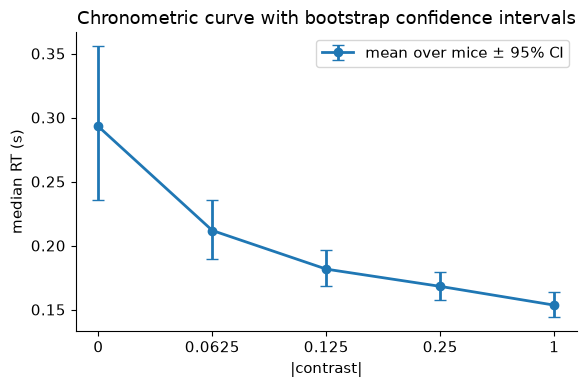

One (B × mice) index array gave CIs for all 5 contrast levels at once.


In [38]:
# TODO 8a - fill in the blanks marked ____, uncomment, and run.

# A = pivot.to_numpy()                              # (n_mice, n_levels)
# n_mice, n_levels = A.shape
# B = 5_000
# # Conceptually simplest, an explicit loop over the B bootstrap replicates:
# boot = np.empty((B, n_levels))
# for b in range(B):
#     take    = rng.integers(0, n_mice, size=n_mice)   # resample mice with replacement
#     boot[b] = A[take].mean(axis=0)                   # mean over the resampled mice
# # Exactly the same, shorter: build all B index rows at once and let fancy indexing do the loop.
# idx  = rng.integers(0, ____, size=(B, n_mice))   # (1) indices in [0, n_mice)   # (B, n_mice) resampled mouse indices
# boot = A[idx].mean(axis=____)                       # (2) average over the resampled-mice axis
# lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)  # a CI for every contrast
# centre = A.mean(axis=0)
#
# fig, ax = plt.subplots()
# xpos = np.arange(n_levels)
# ax.errorbar(xpos, centre, yerr=[centre - lo, hi - centre], fmt="o-", color="#1f77b4",
#             capsize=4, lw=2, label="mean over mice ± 95% CI")
# ax.set_xticks(xpos); ax.set_xticklabels([f"{c:g}" for c in pivot.columns])
# ax.set_xlabel("|contrast|"); ax.set_ylabel("median RT (s)")
# ax.set_title("Chronometric curve with bootstrap confidence intervals")
# ax.legend(); plt.tight_layout(); plt.show()
# print(f"One (B × mice) index array gave CIs for all {n_levels} contrast levels at once.")

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
A = pivot.to_numpy()                              # (n_mice, n_levels)
n_mice, n_levels = A.shape
B = 5_000
# Conceptually simplest, an explicit loop over the B bootstrap replicates:
boot = np.empty((B, n_levels))
for b in range(B):
    take    = rng.integers(0, n_mice, size=n_mice)   # resample mice with replacement
    boot[b] = A[take].mean(axis=0)                   # mean over the resampled mice
# Exactly the same, shorter: build all B index rows at once and let fancy indexing do the loop.
idx  = rng.integers(0, n_mice, size=(B, n_mice))   # (B, n_mice) resampled mouse indices
boot = A[idx].mean(axis=1)                          # (B, n_levels), no Python loop
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)  # a CI for every contrast
centre = A.mean(axis=0)

fig, ax = plt.subplots()
xpos = np.arange(n_levels)
ax.errorbar(xpos, centre, yerr=[centre - lo, hi - centre], fmt="o-", color="#1f77b4",
            capsize=4, lw=2, label="mean over mice ± 95% CI")
ax.set_xticks(xpos); ax.set_xticklabels([f"{c:g}" for c in pivot.columns])
ax.set_xlabel("|contrast|"); ax.set_ylabel("median RT (s)")
ax.set_title("Chronometric curve with bootstrap confidence intervals")
ax.legend(); plt.tight_layout(); plt.show()
print(f"One (B × mice) index array gave CIs for all {n_levels} contrast levels at once.")
# --- END SOLUTION


<a id="section-9"></a>
## 9. Optional (at home): does the bootstrap keep its promise?  *(optional)*

*Another optional take-home extension.* A 95% confidence interval makes a **frequency promise**: if you
repeated the whole experiment many times, about 95% of the intervals would contain the true value. We can
**check** that promise by simulation. Treat the full dataset as the "population", so we know its true
median and true 99th percentile, then repeatedly (i) draw a fresh sample of size `n`, (ii) build a
bootstrap 95% CI from it, and (iii) record whether the CI covers the truth. The fraction that do is the
**empirical coverage**; it should sit near 0.95 if the method is trustworthy for that statistic.

> **▶ Task 9a: Coverage check, where the bootstrap holds and where it breaks. ★★★ _(optional, at home)_**
>
> 1. Write `coverage(statfun, truth, n)` that runs many simulated experiments: each draws `n` reaction
>    times, builds a **vectorised** bootstrap 95% percentile CI of `statfun`, and checks whether it contains
>    `truth`. Return the fraction of experiments whose CI covered the truth.
> 2. Run it for the **median** and for the **99th percentile** of RT, at `n = 30` and `n = 100`.
> 3. In a comment: which estimand keeps the 95% promise, and which under-covers? Why do extreme quantiles
>    and small `n` break the bootstrap?

In [39]:
# TODO 9a - fill in the blanks marked ____, uncomment, and run, then answer in the comment.

# rt_all   = valid["reaction_time_s"].to_numpy()
# med_true = np.median(rt_all)
# q99_true = np.percentile(rt_all, 99)
#
# def coverage(statfun, truth, n, n_exp=200, B=500):
#     hits = 0
#     for _ in range(n_exp):
#         s  = rng.choice(rt_all, size=n, replace=False)   # one experiment
#         bs = rng.choice(s, size=(B, n), replace=True)    # vectorised bootstrap
#         boot = statfun(bs, axis=____)     # (1) apply the statistic across each sample (axis 1)
#         lo, hi = np.percentile(boot, [2.5, 97.5])
#         hits += (____ <= truth <= ____)   # (2) is the true value inside [lo, hi]?
#     return hits / n_exp
#
# def q99(a, axis): return np.percentile(a, 99, axis=axis)   # the statistic passed to coverage()
# for n in [30, 100]:
#     cm = coverage(np.median, med_true, n)
#     cq = coverage(q99,       q99_true, n)
#     print(f"n={n:4d}:  median CI coverage = {cm:.2f}   99th-pct CI coverage = {cq:.2f}")
# # The median CI keeps its ~95% promise; the 99th-percentile CI badly under-covers, worse
# # at small n: the bootstrap can never resample a value beyond the sample maximum, so it
# # systematically underestimates the spread of extreme quantiles.
# # Then answer here: why does the 99th-percentile CI under-cover, especially at small n?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
rt_all   = valid["reaction_time_s"].to_numpy()
med_true = np.median(rt_all)
q99_true = np.percentile(rt_all, 99)

def coverage(statfun, truth, n, n_exp=200, B=500):
    hits = 0
    for _ in range(n_exp):
        s  = rng.choice(rt_all, size=n, replace=False)   # one experiment
        bs = rng.choice(s, size=(B, n), replace=True)    # vectorised bootstrap
        boot = statfun(bs, axis=1)
        lo, hi = np.percentile(boot, [2.5, 97.5])
        hits += (lo <= truth <= hi)
    return hits / n_exp

def q99(a, axis): return np.percentile(a, 99, axis=axis)   # the statistic passed to coverage()
for n in [30, 100]:
    cm = coverage(np.median, med_true, n)
    cq = coverage(q99,       q99_true, n)
    print(f"n={n:4d}:  median CI coverage = {cm:.2f}   99th-pct CI coverage = {cq:.2f}")
# The median CI keeps its ~95% promise; the 99th-percentile CI badly under-covers, worse
# at small n: the bootstrap can never resample a value beyond the sample maximum, so it
# systematically underestimates the spread of extreme quantiles.
# --- END SOLUTION


n=  30:  median CI coverage = 0.94   99th-pct CI coverage = 0.26
n= 100:  median CI coverage = 0.96   99th-pct CI coverage = 0.64


<a id="about"></a>
## 10. About this notebook

**Dataset.** `data/ibl_2afc.csv`, a course subset of the public IBL behavioural release (trials from the
`trained` and `training` phases), built by `data_prep/build_ibl_dataset.py`. See
`data/ibl_2afc_datadictionary.md` for the meaning, units and IBL source of every column.

**Concepts → code map.**
- *Normality checks* → `scipy.stats.probplot` (Q–Q), `stats.normaltest`; the p-value-vs-`n` demonstration.
- *Robust statistics* → median, IQR, `stats.median_abs_deviation`; outlier sensitivity.
- *Non-parametric tests* → `stats.mannwhitneyu`, `stats.wilcoxon`, `stats.kruskal`, `stats.friedmanchisquare`;
  Mann–Whitney U from ranks by hand (`stats.rankdata`); rank-biserial / Cliff's δ effect size.
- *Permutation tests* → `rng.permutation` (sampling without replacement), sign-flip for paired data;
  Monte-Carlo null and exchangeability; exact enumeration (`math.comb`, `itertools.combinations`).
- *Bootstrap CIs* → `rng.choice(..., replace=True)`; **percentile** and **basic (reverse-percentile)**
  intervals; vectorised `(B × n)` resampling for many features at once.

**Further reading.**
- Efron & Tibshirani (1993) *An Introduction to the Bootstrap*, the canonical reference.
- Good (2005) *Permutation, Parametric and Bootstrap Tests of Hypotheses*, permutation logic in depth.
- Wilcox (2017) *Introduction to Robust Estimation and Hypothesis Testing*, robust statistics.
- The IBL et al. (2021) *eLife* 10:e63711, the standardized IBL behavioural task.

**Credits.** Week 6, Responsible TAs: Théo & Konstantin,  contributing TA: Benjamin. Quantitative Methods in Neuroscience,
University of Geneva (2026-27).